In [1]:
# Libraries
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"C:\Users\kalak\Downloads\bridge_data.csv")
df

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
0,80,60,Concrete,No-Maintainance,0
1,44,2516,Steel,Bi-Annual,0
2,61,4406,Concrete,Annual,1
3,93,2082,Steel,No-Maintainance,1
4,62,4159,Steel,No-Maintainance,0
...,...,...,...,...,...
715,6,2964,Concrete,Annual,0
716,90,3637,Concrete,No-Maintainance,0
717,42,2134,Concrete,Annual,0
718,92,778,Steel,No-Maintainance,0


In [3]:
df.shape

(720, 5)

In [4]:
df.columns

Index(['Age_of_Bridge', 'Traffic_Volume', 'Material_Type', 'Maintenance_Level',
       'Bridge_Condition'],
      dtype='str')

In [5]:
type(df)

pandas.DataFrame

In [6]:
df.size

3600

In [7]:
df.head()

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
0,80,60,Concrete,No-Maintainance,0
1,44,2516,Steel,Bi-Annual,0
2,61,4406,Concrete,Annual,1
3,93,2082,Steel,No-Maintainance,1
4,62,4159,Steel,No-Maintainance,0


In [8]:
df.tail()

,Age_of_Bridge,Traffic_Volume,Material_Type,Maintenance_Level,Bridge_Condition
715,6,2964,Concrete,Annual,0
716,90,3637,Concrete,No-Maintainance,0
717,42,2134,Concrete,Annual,0
718,92,778,Steel,No-Maintainance,0
719,15,1391,Steel,Bi-Annual,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age_of_Bridge      720 non-null    int64
 1   Traffic_Volume     720 non-null    int64
 2   Material_Type      720 non-null    str  
 3   Maintenance_Level  720 non-null    str  
 4   Bridge_Condition   720 non-null    int64
dtypes: int64(3), str(2)
memory usage: 40.0 KB


In [10]:
df.describe()

,Age_of_Bridge,Traffic_Volume,Bridge_Condition
count,720.000000,720.000000,720.000000
mean,49.033333,2420.827778,0.140278
std,29.469467,1423.863663,0.347516
min,1.000000,51.000000,0.000000
25%,23.000000,1106.000000,0.000000
50%,49.000000,2377.000000,0.000000
75%,75.000000,3605.000000,0.000000
max,99.000000,4994.000000,1.000000


In [11]:
df.dtypes

Age_of_Bridge        int64
Traffic_Volume       int64
Material_Type          str
Maintenance_Level      str
Bridge_Condition     int64
dtype: object

In [12]:
df.duplicated().sum()

np.int64(128)

In [13]:
df.isnull().sum()

Age_of_Bridge        0
Traffic_Volume       0
Material_Type        0
Maintenance_Level    0
Bridge_Condition     0
dtype: int64

In [14]:
df.nunique()

Age_of_Bridge         99
Traffic_Volume       559
Material_Type          2
Maintenance_Level      3
Bridge_Condition       2
dtype: int64

In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_").str.replace(" ","-")
df.columns

Index(['age_of_bridge', 'traffic_volume', 'material_type', 'maintenance_level',
       'bridge_condition'],
      dtype='str')

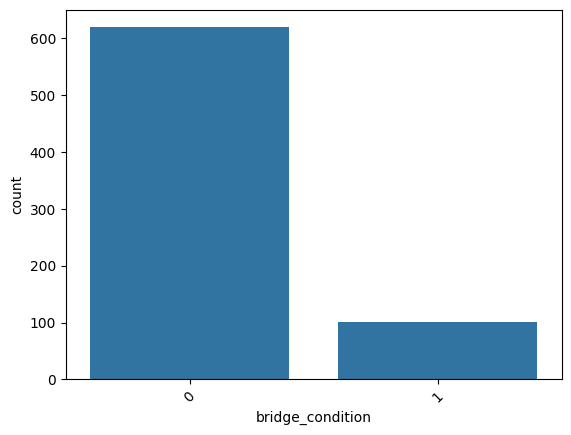

In [16]:
sns.countplot(x="bridge_condition", data=df)
plt.xticks(rotation =45)
plt.show()

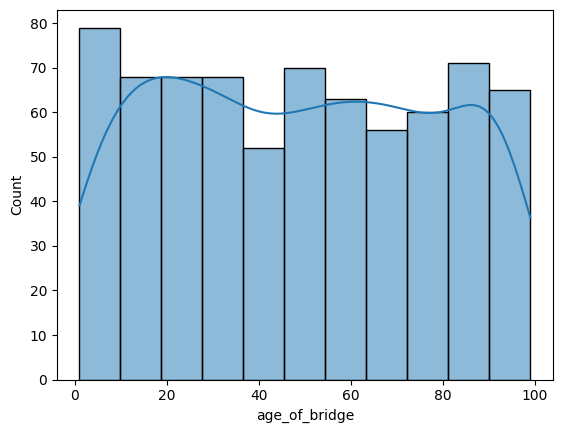

In [17]:
sns.histplot(df["age_of_bridge"], kde=True)
plt.show()

In [18]:
print(df[['age_of_bridge','traffic_volume']].skew())

age_of_bridge     0.035487
traffic_volume    0.050646
dtype: float64


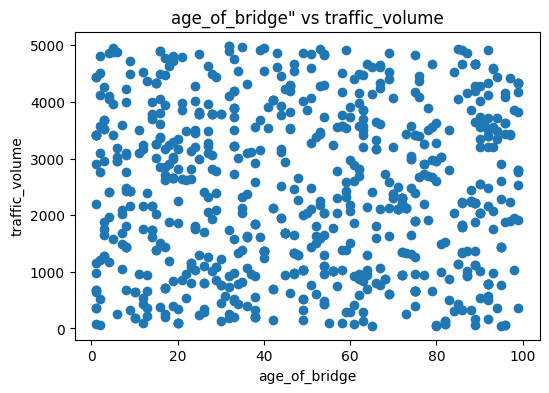

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(df['age_of_bridge'], df['traffic_volume'])

plt.title('age_of_bridge" vs traffic_volume')
plt.xlabel('age_of_bridge')
plt.ylabel('traffic_volume')

plt.show()

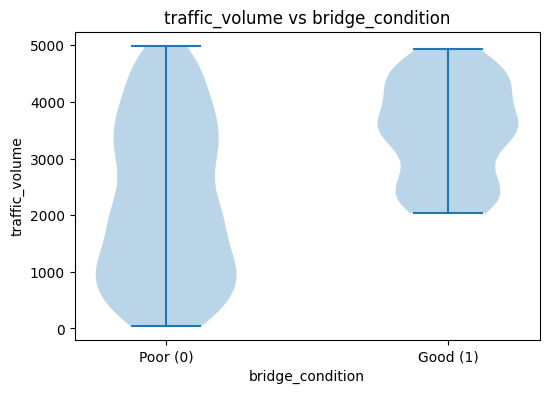

In [20]:
plt.figure(figsize=(6,4))

data_0 = df[df['bridge_condition'] == 0]['traffic_volume']
data_1 = df[df['bridge_condition'] == 1]['traffic_volume']

plt.violinplot([data_0, data_1])

plt.xticks([1,2], ['Poor (0)', 'Good (1)'])
plt.title('traffic_volume vs bridge_condition')
plt.xlabel('bridge_condition')
plt.ylabel('traffic_volume')

plt.show()

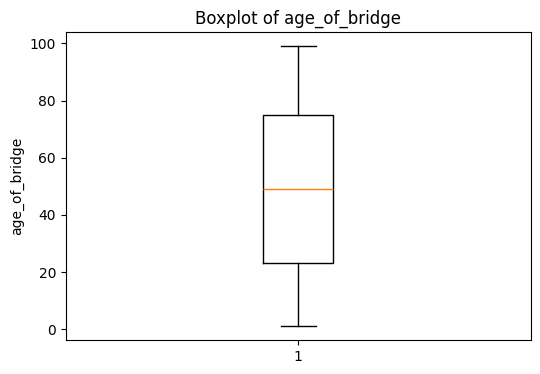

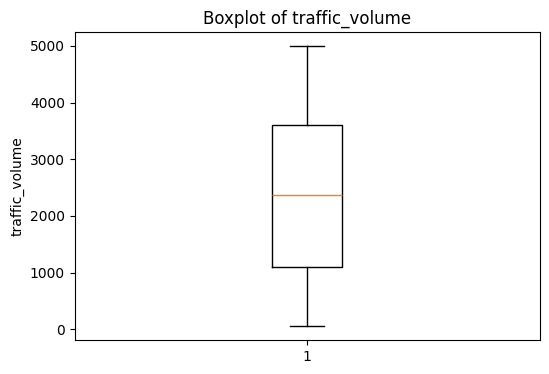

In [21]:
# Select Numerical Columns
numerical_columns = ['age_of_bridge', 'traffic_volume']

# Create Boxplots
for col in numerical_columns:
    
    plt.figure(figsize=(6,4))
    
    plt.boxplot(df[col])
    
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    
    plt.show()

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# Features (X) and Target (y)
X = df.drop('bridge_condition', axis=1)
y = df['bridge_condition']

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,     
    test_size=0.2,   # 20% testing data
    random_state=42  # for same output every time
)

In [25]:
# Display shapes
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (576, 4)
X_test shape  : (144, 4)
y_train shape : (576,)
y_test shape  : (144,)


In [29]:
from sklearn.preprocessing import LabelEncoder

# Create Label Encoder Object
le = LabelEncoder()

# Apply Label Encoding
df['material_type'] = le.fit_transform(df['material_type'])
df['material_type'].head()

0    0
1    1
2    0
3    1
4    1
Name: material_type, dtype: int64

In [30]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Convert categorical columns into numerical values
df['maintenance_level'] = le.fit_transform(df['maintenance_level'])

# Display dataset
print(df.head())

   age_of_bridge  traffic_volume  material_type  maintenance_level  \
0             80              60              0                  2   
1             44            2516              1                  1   
2             61            4406              0                  0   
3             93            2082              1                  2   
4             62            4159              1                  2   

   bridge_condition  
0                 0  
1                 0  
2                 1  
3                 1  
4                 0  


In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# feature scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\kalak\AppData\Local\Temp\ipykernel_22516\227296332.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include='object').columns:


In [39]:
X_test_scaled

array([[ 0.18945605, -1.04744937,  0.9459053 , -0.04682971],
       [ 1.37194335, -1.69753749, -1.05718828,  1.17925737],
       [-0.52003633,  0.79025811, -1.05718828, -0.04682971],
       [ 0.62866562,  0.86240996, -1.05718828, -0.04682971],
       [ 1.47329941,  0.78737204, -1.05718828, -1.2729168 ],
       [ 0.18945605, -0.79924703,  0.9459053 , -0.04682971],
       [-0.14839746,  0.51247351,  0.9459053 ,  1.17925737],
       [ 1.03408984,  1.62577647, -1.05718828, -1.2729168 ],
       [ 0.69623632, -0.56403201, -1.05718828,  1.17925737],
       [-0.99303125,  1.73111817, -1.05718828,  1.17925737],
       [-1.56738223,  0.25633446,  0.9459053 ,  1.17925737],
       [ 1.47329941, -1.17587966,  0.9459053 ,  1.17925737],
       [-0.82410449,  0.75273915, -1.05718828,  1.17925737],
       [-0.52003633, -1.02580382, -1.05718828, -0.04682971],
       [-0.35110957, -1.58714517, -1.05718828, -1.2729168 ],
       [-1.19574336, -1.47242374,  0.9459053 , -1.2729168 ],
       [ 1.23680195, -1.

In [40]:
from sklearn.preprocessing import MinMaxScaler

In [46]:
mn=MinMaxScaler()
X_train= mn.fit_transform(X_train)

In [48]:
X_train=pd.DataFrame(X_train)
X_train

,0,1,2,3
0,0.867347,0.360914,1.0,0.0
1,0.071429,0.607526,1.0,0.5
2,0.112245,0.629173,0.0,0.0
3,0.663265,0.630386,1.0,0.0
4,0.622449,0.185919,0.0,0.0
...,...,...,...,...
571,0.265306,0.615011,1.0,0.0
572,0.653061,0.924135,0.0,1.0
573,0.591837,0.458021,1.0,0.5
574,0.163265,0.041675,0.0,0.5


In [51]:
mn=MinMaxScaler()
X_test = mn.fit_transform(X_test)

X_test

array([[0.54081633, 0.18242559, 1.        , 0.5       ],
       [0.89795918, 0.        , 0.        , 1.        ],
       [0.32653061, 0.69811703, 0.        , 0.5       ],
       [0.67346939, 0.71836404, 0.        , 0.5       ],
       [0.92857143, 0.69730715, 0.        , 0.        ],
       [0.54081633, 0.25207532, 1.        , 0.5       ],
       [0.43877551, 0.62016603, 1.        , 1.        ],
       [0.79591837, 0.93257744, 0.        , 0.        ],
       [0.69387755, 0.31808058, 0.        , 1.        ],
       [0.18367347, 0.96213808, 0.        , 1.        ],
       [0.01020408, 0.54828913, 1.        , 1.        ],
       [0.92857143, 0.14638591, 1.        , 1.        ],
       [0.23469388, 0.68758858, 0.        , 1.        ],
       [0.32653061, 0.1884997 , 0.        , 0.5       ],
       [0.37755102, 0.03097793, 0.        , 0.        ],
       [0.12244898, 0.06317068, 1.        , 0.        ],
       [0.85714286, 0.07491395, 0.        , 1.        ],
       [0.23469388, 0.80178174,

In [53]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.81.1-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached opt

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.3 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [54]:
from keras.models import Sequential

In [55]:
from keras.layers import Dense

## intialize seqeuntial model

In [56]:
model = Sequential()

In [57]:
model.add(Dense(units=64,activation ="relu",input_shape =(X_train.shape[1],)))
# hidden layer
model.add(Dense(units = 20 , activation ="relu"))
#output layer
model.add(Dense(units= 3,activation = "softmax"))

C:\Users\kalak\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
## complie model
model.compile(optimizer ="adam",loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"])

## train the model 

In [61]:
history = model.fit(X_train,y_train,batch_size = 8,epochs =5,verbose =1,validation_split = 0.2)
history

Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8652 - loss: 0.3573 - val_accuracy: 0.8879 - val_loss: 0.3252
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3279 - val_accuracy: 0.8879 - val_loss: 0.3377
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3043 - val_accuracy: 0.8879 - val_loss: 0.2931
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8609 - loss: 0.2893 - val_accuracy: 0.8707 - val_loss: 0.2956
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8652 - loss: 0.2683 - val_accuracy: 0.8879 - val_loss: 0.2753


## evaluate

In [62]:
ac = model.evaluate(X_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8125 - loss: 0.3774


In [ ]:
import gensim
from gensim.models import fasteText

In [ ]:
train with FasteText

In [ ]:
from gensim.models import FasteText
model = FasteText( Sentences = sentences , vector_size= 100,
                  Window = 3 , min_count = 1,)
                  

In [ ]:
print("similar words to "learning": ")
print(model.wv.most_similar("learning" , topn = 5))

In [ ]:
get word vector 

In [ ]:
vector  = model.wv["learning"]

In [ ]:
print(model.wv["run"][:10]) 